# QuRad vs PyRadiomics Comparison

This notebook compares radiomics features extracted by:
1. **QuRad** - QuPath Groovy extension
2. **PyRadiomics** - Python package

## Setup

### Loading Example Data into QuPath

1. **Open QuPath**
2. **File > Open** and select: `QuRad/example_data/subfolder/image.tif`
3. **File > Import Objects from File** and select `QuRad/example_data/subfolder/cell_detections.geojson`
4. **Run QuRad script**: `Automate > Script editor > Open > QuPath_Radiomics_v3.groovy`
5. **Click Run** - This generates a CSV file in `/radiomics/`

The example data includes:

**Breast cancer data - single tile**

- `image.tif` - RGB H&E image (converted to grayscale during processing)
- `labels.tif` - Labeled mask (uint16, each cell has unique integer value 1, 2, 3...)
- `cell_info.csv` - Maps cells to labels
- `cell_detections.geojson` - Cell detections to be imported in QuPath

**GBM data - full WSI**
- tbd

## Workflow
1. Load example image and labels
2. Run Python pyradiomics on the image + labeled mask
3. Compare feature values with QuRad results

## Loading

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
import os
from pathlib import Path
import SimpleITK as sitk
from radiomics import featureextractor
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [2]:
NOTEBOOK_DIR = Path(os.getcwd())  # Current working directory
BASE_DIR = Path("/Users/tamara/Desktop/PyRadiomics")
QUPATH_RADIOMICS_DIR = BASE_DIR / "Qupath" / "radiomics"

# Example data gbm
#IMAGE_PATH = EXAMPLE_DATA_DIR / "ILR192-11-17-36-45_8367_10109_z0_t0.tif"
#LABELS_PATH = EXAMPLE_DATA_DIR / "ILR192-11-17-36-45_8367_10109_z0_t0_cp_masks.tif"

# Example data breast_cancer
EXAMPLE_DATA_DIR = BASE_DIR / "QuRad" / "example_data" / "breast_cancer"
IMAGE_PATH = EXAMPLE_DATA_DIR / "ytma10_010704_benign1_ccd.tif"
LABELS_PATH = EXAMPLE_DATA_DIR / "ytma10_010704_benign1_ccd_labels.tif"

QURAD_CSV_DIR = QUPATH_RADIOMICS_DIR

print(f"Example data directory: {EXAMPLE_DATA_DIR}")
print(f"Image: {IMAGE_PATH}")
print(f"Labels: {LABELS_PATH}")
print(f"QuRad results directory: {QURAD_CSV_DIR}")

Example data directory: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/breast_cancer
Image: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/breast_cancer/ytma10_010704_benign1_ccd.tif
Labels: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/breast_cancer/ytma10_010704_benign1_ccd_labels.tif
QuRad results directory: /Users/tamara/Desktop/PyRadiomics/Qupath/radiomics


In [3]:
# Load example image and labels
if not IMAGE_PATH.exists() or not LABELS_PATH.exists():
    print("✗ Example data not found!")
    print(f"  Expected:")
    print(f"    Image: {IMAGE_PATH}")
    print(f"    Labels: {LABELS_PATH}")
    print(f"\n  Please ensure the example data files exist.")
else:
    # Load label mask (uint16 grayscale)
    labels = np.array(Image.open(LABELS_PATH)).astype(np.int32)
    print(f"✓ Loaded label mask")
    print(f"  Shape: {labels.shape}")
    print(f"  Dtype: {labels.dtype}")
    
    unique_labels = np.unique(labels)
    # Exclude background (label 0)
    cell_labels = unique_labels[unique_labels > 0]
    print(f"  Unique labels (including background): {len(unique_labels)}")
    print(f"  Cell labels: {len(cell_labels)}")
    print(f"  Label range: {cell_labels.min()} to {cell_labels.max()}")
    
    # Load image (will be converted to grayscale later)
    img = np.array(Image.open(IMAGE_PATH))
    print(f"\n✓ Loaded image")
    print(f"  Shape: {img.shape}")
    print(f"  Dtype: {img.dtype}")

✓ Loaded label mask
  Shape: (768, 896)
  Dtype: int32
  Unique labels (including background): 411
  Cell labels: 410
  Label range: 1 to 410

✓ Loaded image
  Shape: (768, 896, 3)
  Dtype: uint8


## Exporting mask for QuPath

Save labels.tif as cell_detections.geojson

In [4]:
import json
from skimage import measure
from shapely.geometry import Polygon, MultiPolygon, mapping

OUTPUT_GEOJSON = EXAMPLE_DATA_DIR / "cell_detections.geojson"

features = []

for label_id in cell_labels:
    binary = (labels == label_id).astype(np.uint8)

    # Extract contours at pixel-accurate boundary
    contours = measure.find_contours(binary, level=0.5)

    polygons = []
    for contour in contours:
        # contour is (row, col) → convert to (x, y)
        poly = Polygon(contour[:, ::-1])

        # Filter tiny artifacts
        if poly.area >= 5:
            polygons.append(poly)

    if not polygons:
        continue

    geom = polygons[0] if len(polygons) == 1 else MultiPolygon(polygons)

    features.append({
        "type": "Feature",
        "geometry": mapping(geom),
        "properties": {
            "label_id": int(label_id),
            "object_type": "detection"
        }
    })

geojson = {
    "type": "FeatureCollection",
    "features": features
}

with open(OUTPUT_GEOJSON, "w") as f:
    json.dump(geojson, f)

print(f"✓ Exported {len(features)} cell detections")
print(f"→ {OUTPUT_GEOJSON}")


✓ Exported 410 cell detections
→ /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/breast_cancer/cell_detections.geojson


## Configure PyRadiomics

Set up the feature extractor with settings matching QuRad.

In [5]:
# Configure pyradiomics to match QuRad settings
settings = {
    'binWidth': 25,  # Same as QuRad
    'resampledPixelSpacing': None,  # No resampling
    'interpolator': sitk.sitkBSpline,
    'force2D': True,
    'force2Ddimension': 0,
    'normalize': False,
    'normalizeScale': 1,
    'removeOutliers': None,
    'voxelArrayShift': 0,
}

# Initialize the feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)

# Enable feature classes matching QuRad
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('shape2D')
extractor.enableFeatureClassByName('shape')
extractor.enableFeatureClassByName('glcm')
extractor.enableFeatureClassByName('glrlm')
extractor.enableFeatureClassByName('glszm')
extractor.enableFeatureClassByName('ngtdm')
extractor.enableFeatureClassByName('gldm')

print("PyRadiomics Feature Extractor configured")
print(f"\nEnabled feature classes:")
for cls in extractor.enabledFeatures.keys():
    print(f"  - {cls}")

PyRadiomics Feature Extractor configured

Enabled feature classes:
  - firstorder
  - shape2D
  - shape
  - glcm
  - glrlm
  - glszm
  - ngtdm
  - gldm


## Extract PyRadiomics Features

Extract features for each labeled cell in the mask.

In [6]:
def extract_features_for_label(image_sitk, labels_sitk, label_value):
    """Extract pyradiomics features for a single label."""
    try:
        # Create binary mask for this label
        mask = sitk.Cast(labels_sitk == label_value, sitk.sitkInt32)
        
        # Check if mask has any pixels
        mask_array = sitk.GetArrayFromImage(mask)
        if mask_array.sum() == 0:
            return None
        
        # Calculate centroid from mask for spatial matching
        y_coords, x_coords = np.where(mask_array[0] > 0)  # Get coordinates (z, y, x) -> [0] for first slice
        if len(y_coords) == 0:
            return None
        centroid_y = float(np.mean(y_coords))
        centroid_x = float(np.mean(x_coords))
        
        # Extract features
        result = extractor.execute(image_sitk, mask, label=1)
        
        # Filter to only radiomics features (exclude diagnostics)
        features = {k: float(v) for k, v in result.items() 
                   if not k.startswith('diagnostics_')}
        
        # Add centroid coordinates for spatial matching with QuRad
        features['CentroidX'] = centroid_x
        features['CentroidY'] = centroid_y
        
        return features
    except Exception as e:
        return None

In [7]:
# Extract features for all labeled cells
pyrad_results = []

if 'img' in dir() and 'labels' in dir():
    # Convert to grayscale using same method as QuRad (luminance conversion)
    if len(img.shape) == 3 and img.shape[2] == 3:
        # QuRad uses: 0.299*R + 0.587*G + 0.114*B
        gray_2d = (img[:,:,0] * 0.299 + 
                   img[:,:,1] * 0.587 + 
                   img[:,:,2] * 0.114).astype(np.float32)
        print(f"✓ Converted RGB to grayscale using luminance weights (matching QuRad)")
    elif len(img.shape) == 2:
        gray_2d = img.astype(np.float32)
        print(f"✓ Image is already grayscale")
    else:
        gray_2d = img.squeeze().astype(np.float32)
        print(f"✓ Squeezed image to 2D")
    
    # Add a dimension for SimpleITK (expects 3D for force2D)
    gray_3d = gray_2d[np.newaxis, :, :]
    labels_3d = labels[np.newaxis, :, :].astype(np.int32)
    
    image_sitk = sitk.GetImageFromArray(gray_3d)
    labels_sitk = sitk.GetImageFromArray(labels_3d)
    
    print(f"Image shape for PyRadiomics: {sitk.GetArrayFromImage(image_sitk).shape}")
    print(f"Labels shape for PyRadiomics: {sitk.GetArrayFromImage(labels_sitk).shape}")
    
    # Get all cell labels (exclude background)
    cell_labels = np.unique(labels)
    cell_labels = cell_labels[cell_labels > 0]
    total_cells = len(cell_labels)
    
    # Limit to first N cells for testing (remove or increase for full extraction)
    max_cells = min(1000, total_cells)  # Set to total_cells for all
    
    print(f"\nExtracting PyRadiomics features for {max_cells} cells...\n")
    
    for idx, label_value in enumerate(cell_labels[:max_cells]):
        features = extract_features_for_label(image_sitk, labels_sitk, label_value)
        
        if features:
            features['label'] = int(label_value)
            # Use label as cell_id since we don't have QuPath IDs
            features['cell_id'] = f"label_{label_value}"
            pyrad_results.append(features)
        
        # Progress update
        if (idx + 1) % 20 == 0:
            print(f"  Processed {idx + 1}/{max_cells} cells...")
    
    print(f"\n✓ Extracted features for {len(pyrad_results)} cells")
else:
    print("Please run previous cells to load the example data.")

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


✓ Converted RGB to grayscale using luminance weights (matching QuRad)
Image shape for PyRadiomics: (1, 768, 896)
Labels shape for PyRadiomics: (1, 768, 896)

Extracting PyRadiomics features for 410 cells...



GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

  Processed 20/410 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

...

  Processed 380/410 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

  Processed 400/410 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated



✓ Extracted features for 410 cells


In [8]:
# Create DataFrame from PyRadiomics results
if pyrad_results:
    pyrad_df = pd.DataFrame(pyrad_results)
    print(f"PyRadiomics DataFrame shape: {pyrad_df.shape}")
    print(f"\nFeature classes extracted:")
    
    # Count features by class
    feature_counts = {}
    for col in pyrad_df.columns:
        if '_' in col and col not in ['label', 'cell_id']:
            prefix = col.split('_')[1]  # original_firstorder_X -> firstorder
            feature_counts[prefix] = feature_counts.get(prefix, 0) + 1
    
    for cls, count in sorted(feature_counts.items()):
        print(f"  {cls}: {count} features")
    
    print(f"\nTotal features: {sum(feature_counts.values())}")
    display(pyrad_df.head())

PyRadiomics DataFrame shape: (410, 120)

Feature classes extracted:
  firstorder: 18 features
  glcm: 24 features
  gldm: 14 features
  glrlm: 16 features
  glszm: 16 features
  ngtdm: 5 features
  shape: 14 features
  shape2D: 9 features

Total features: 116


,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,...,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,CentroidX,CentroidY,label,cell_id
0,0.701700,0.0,0.0,33.351022,32.0,23.0,35.468296,35.468296,576.666667,23.402404,...,401.334448,6.352367,0.152709,0.040600,0.375727,0.007034,276.894649,289.926421,1,label_1
1,0.583385,0.0,0.0,33.982555,29.0,23.0,33.837849,33.837849,499.416667,19.824928,...,484.535645,6.812938,0.142579,0.033304,0.357421,0.004746,611.799615,398.780347,2,label_2
2,0.694449,0.0,0.0,30.356777,30.0,21.0,30.594117,30.594117,482.166667,21.081221,...,553.247505,6.915947,0.123774,0.027412,0.285212,0.004152,552.856287,403.976048,3,label_3
3,0.843890,0.0,0.0,26.879642,24.0,25.0,27.802878,27.802878,458.916667,22.683452,...,195.794549,24.760599,0.462439,0.031959,0.135052,0.012751,73.884696,414.144654,4,label_4
4,0.515537,0.0,0.0,33.840138,20.0,28.0,33.241540,33.241540,437.416667,17.445844,...,324.313596,11.794126,0.236256,0.040602,0.382165,0.008899,160.177632,638.912281,5,label_5


## Load QuRad Results

In [9]:
# Load cell mapping (label ID -> QuPath ObjectID)
cell_mapping_path = EXAMPLE_DATA_DIR / "cell_info.csv"

if cell_mapping_path.exists():
    cell_mapping = pd.read_csv(cell_mapping_path)
    print(f"✓ Loaded cell mapping: {len(cell_mapping)} cells")
    print(f"  Columns: {list(cell_mapping.columns)}")
    display(cell_mapping.head())
else:
    print(f"Cell mapping not found: {cell_mapping_path}")

✓ Loaded cell mapping: 410 cells
  Columns: ['label', 'cell_id', 'classification', 'x', 'y', 'width', 'height', 'area', 'centroid_x', 'centroid_y']


,label,cell_id,classification,x,y,width,height,area,centroid_x,centroid_y
0,1,c2c897d3-0a1c-40ae-a94e-e02b9252c18d,Unclassified,261.0,278.0,34.0,23.0,598.0,277.394653,290.426422
1,2,f1fd9206-00fa-46c6-87ea-1f33ad99d50d,Unclassified,596.0,386.0,30.0,25.0,519.0,612.299622,399.280334
2,3,f7e85319-d423-4211-b6a8-fe89ff50aafa,Unclassified,538.0,394.0,30.0,21.0,501.0,553.356262,404.476044
3,4,33ad606f-4cd1-4875-a1a7-fe9a77e144b5,Unclassified,62.0,402.0,25.0,25.0,477.0,74.384697,414.644653
4,5,0d15d120-5ff4-486e-8005-33bfbb812dcd,Unclassified,148.0,623.0,24.0,31.0,456.0,160.677628,639.412292


In [10]:
# Find the most recent QuRad CSV
radiomics_dir = QUPATH_RADIOMICS_DIR
qurad_files = sorted(radiomics_dir.glob("*.csv"), reverse=True)

if qurad_files:
    qurad_csv = qurad_files[0]
    print(f"Loading QuRad results from: {qurad_csv.name}")
    
    qurad_df = pd.read_csv(qurad_csv)
    print(f"QuRad DataFrame shape: {qurad_df.shape}")
    
    # Count features by class
    print(f"\nFeature classes:")
    feature_counts = {}
    for col in qurad_df.columns:
        if '_' in col and col not in ['ObjectID', 'ObjectType', 'Classification']:
            prefix = col.split('_')[0]
            feature_counts[prefix] = feature_counts.get(prefix, 0) + 1
    
    for cls, count in sorted(feature_counts.items()):
        print(f"  {cls}: {count} features")
    
    display(qurad_df.head(2))
else:
    print("No QuRad results found. Run QuPath_Radiomics_v2.groovy first.")

Loading QuRad results from: ytma10_010704_benign1_ccd_tif_radiomics_20251216_162601.csv
QuRad DataFrame shape: (411, 123)

Feature classes:
  firstorder: 19 features
  glcm: 23 features
  gldm: 15 features
  glrlm: 16 features
  glszm: 16 features
  ngtdm: 5 features
  shape: 16 features
  shape2D: 10 features


,Classification,ObjectID,ObjectType,firstorder_10Percentile,firstorder_90Percentile,firstorder_Energy,firstorder_Entropy,firstorder_InterquartileRange,firstorder_Kurtosis,firstorder_Maximum,...,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,shape_SphericalDisproportion,shape_Sphericity,shape_SurfaceArea,shape_SurfaceVolumeRatio,shape_VoxelVolume
0,Unclassified,8d89d871-3c2c-4e41-bbe6-f5b8c1eb55e1,Annotation,113.0,147.0,2784923.0,1.262036,18.0,2.615298,161.0,...,15.0,21.213203,21.213203,160.0,15.0,1.790493,0.558505,60.0,0.375000,160.0
1,Unclassified,42c22bed-98dd-42a0-8c64-06d19e0eaeb4,Annotation,119.0,157.0,6342812.0,1.540798,23.0,3.267990,168.0,...,21.0,28.319605,28.319605,336.0,19.0,1.515761,0.659734,80.0,0.238095,336.0


## Compare Features

Map feature names between QuRad and PyRadiomics and compare values.

In [11]:
# Merge cells: PyRadiomics (by label) + mapping (label→ObjectID) + QuRad (by ObjectID)
mapping = cell_mapping[['label', 'cell_id']].rename(columns={'cell_id': 'ObjectID'})
merged_df = qurad_df.merge(mapping, on='ObjectID').merge(pyrad_df, on='label')
print(f"Matched {len(merged_df)} cells")

# Compare features: QuRad "class_Feature" vs PyRadiomics "original_class_Feature"
qurad_features = [c for c in qurad_df.columns if '_' in c and c not in ['ObjectID', 'ObjectType', 'Classification']]
results = []
for feat in qurad_features:
    pyrad_feat = f'original_{feat}'
    if pyrad_feat in merged_df.columns:
        r = merged_df[feat].corr(merged_df[pyrad_feat])
        results.append({'feature': feat, 'correlation': r})

comparison_df = pd.DataFrame(results)
print(f"Compared {len(comparison_df)} features")
print(f"Median r = {comparison_df['correlation'].median():.4f}")

Matched 410 cells
Compared 112 features
Median r = 0.9992


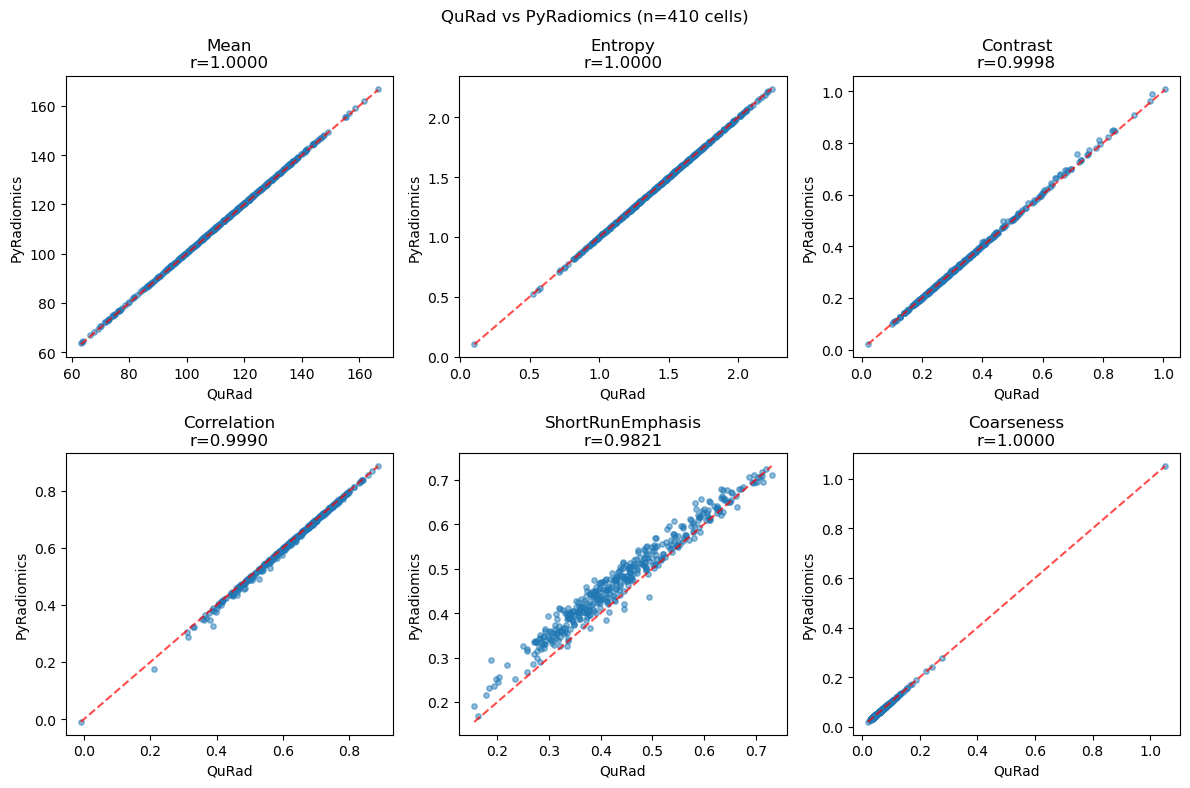

In [12]:
# Plot example feature comparisons
features = ['firstorder_Mean', 'firstorder_Entropy', 'glcm_Contrast', 
            'glcm_Correlation', 'glrlm_ShortRunEmphasis', 'ngtdm_Coarseness']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    pyrad_feat = f'original_{feat}'
    if feat in merged_df.columns and pyrad_feat in merged_df.columns:
        x, y = merged_df[feat], merged_df[pyrad_feat]
        ax.scatter(x, y, alpha=0.5, s=15)
        ax.plot([x.min(), x.max()], [x.min(), x.max()], 'r--', alpha=0.7)
        ax.set_xlabel('QuRad'); ax.set_ylabel('PyRadiomics')
        ax.set_title(f'{feat.split("_",1)[1]}\nr={x.corr(y):.4f}')
plt.suptitle(f'QuRad vs PyRadiomics (n={len(merged_df)} cells)')
plt.tight_layout()
plt.show()

## Summary & Interpretation

### Expected Differences

Some differences between QuRad and PyRadiomics are expected due to:

1. **Shape calculations**: Different algorithms for perimeter/area
2. **Floating point precision**: Minor rounding differences

In [16]:
# Summary statistics
n_total = len(comparison_df)
n_excellent = (comparison_df['correlation'] > 0.95).sum()
n_good = ((comparison_df['correlation'] >= 0.8) & (comparison_df['correlation'] <= 0.95)).sum()
n_lower = (comparison_df['correlation'] < 0.80).sum()

print(f"Features compared: {n_total}")
print(f"Mean correlation: {comparison_df['correlation'].mean():.4f}")
print(f"Median correlation: {comparison_df['correlation'].median():.4f}")
print(f"\nr > 0.95 (excellent): {n_excellent} ({100*n_excellent/n_total:.0f}%)")
print(f"r 0.80–0.95 (good):   {n_good} ({100*n_good/n_total:.0f}%)")
print(f"r < 0.80 (lower):     {n_lower} ({100*n_lower/n_total:.0f}%)")

# Show ALL features with r <= 0.95
imperfect = comparison_df[comparison_df['correlation'] <= 0.95].sort_values('correlation')
print(f"\nAll {len(imperfect)} features with r ≤ 0.95:")
display(imperfect)

Features compared: 112
Mean correlation: 0.9481
Median correlation: 0.9992

r > 0.95 (excellent): 85 (76%)
r 0.80–0.95 (good):   14 (12%)
r < 0.80 (lower):     11 (10%)

All 25 features with r ≤ 0.95:


,feature,correlation
108,shape_Sphericity,-0.063935
80,glszm_SizeZoneNonUniformityNormalized,0.530344
81,glszm_SmallAreaEmphasis,0.664772
99,shape_Elongation,0.668722
92,shape2D_Elongation,0.668722
84,glszm_ZoneEntropy,0.720801
107,shape_MinorAxisLength,0.767323
94,shape2D_MinorAxisLength,0.767323
83,glszm_SmallAreaLowGrayLevelEmphasis,0.770426
79,glszm_SizeZoneNonUniformity,0.781443


## Features Missing in PyRadiomics

List all features that are in QuRad but not available in PyRadiomics.


In [14]:
# Features only in QuRad (no PyRadiomics equivalent)
qurad_features = [c for c in qurad_df.columns if '_' in c and c not in ['ObjectID', 'ObjectType', 'Classification']]
qurad_only = [f for f in qurad_features if f'original_{f}' not in pyrad_df.columns]
print(f"Features only in QuRad: {len(qurad_only)}")
for f in sorted(qurad_only):
    print(f"  - {f}")

Features only in QuRad: 8
  - firstorder_StandardDeviation
  - gldm_DependencePercentage
  - shape2D_Flatness
  - shape2D_MeshSurfaceArea
  - shape2D_SphericalDisproportion
  - shape_Compactness1
  - shape_Compactness2
  - shape_SphericalDisproportion


## Figure 1: Validation Plot for Publication

✓ Saved figure1_validation.pdf and .png


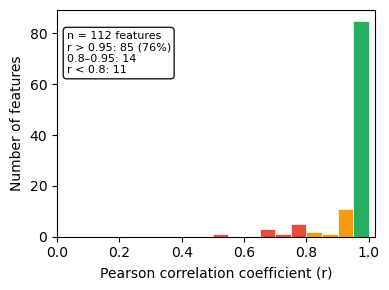

In [17]:
# Figure 1: QuRad vs PyRadiomics Validation
# Simple, clean histogram showing correlation distribution

correlations = comparison_df['correlation'].values
n_total = len(correlations)
median_r = np.median(correlations)
n_excellent = (correlations > 0.95).sum()
n_good = ((correlations >= 0.8) & (correlations <= 0.95)).sum()
n_lower = (correlations < 0.8).sum()

fig, ax = plt.subplots(figsize=(4, 3))

# Histogram
bins = np.arange(0, 1.05, 0.05)
n, _, patches = ax.hist(correlations, bins=bins, edgecolor='white', linewidth=0.5, color='#3498db')

# Color by agreement level
for p, edge in zip(patches, bins[:-1]):
    if edge >= 0.95:
        p.set_facecolor('#27ae60')  # Green - excellent
    elif edge >= 0.8:
        p.set_facecolor('#f39c12')  # Orange - good  
    else:
        p.set_facecolor('#e74c3c')  # Red - lower


ax.set_xlabel('Pearson correlation coefficient (r)', fontsize=10)
ax.set_ylabel('Number of features', fontsize=10)
ax.set_xlim(0, 1.02)

# Stats annotation
stats = f'n = {n_total} features\nr > 0.95: {n_excellent} ({100*n_excellent/n_total:.0f}%)\n0.8–0.95: {n_good}\nr < 0.8: {n_lower}'
ax.text(0.03, 0.72, stats, transform=ax.transAxes, fontsize=8, 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('../article_figures/figure1_validation.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved figure1_validation.pdf and .png")
plt.show()